# Exploratory Data Analysis (EDA) on Loan Application Data

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
%pip install -q missingno 
import missingno as msno

Note: you may need to restart the kernel to use updated packages.


In [20]:
# Load the dataset
df = pd.read_excel('../Data/Data_finance_lab3.xlsx', sheet_name='data_final')
# Display basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   APP_ID                    5000 non-null   int64         
 1   DISBURSALDATE             5000 non-null   datetime64[ns]
 2   REPORT_DATE               5000 non-null   datetime64[ns]
 3   TERM_TMP                  5000 non-null   int64         
 4   PRODUCT_NAME              5000 non-null   object        
 5   LOANAMOUNT_NOT_INSURANCE  5000 non-null   int64         
 6   INSURANCE_FEE             5000 non-null   int64         
 7   LA                        5000 non-null   int64         
 8   EFF_RATE                  5000 non-null   float64       
 9   TERM                      5000 non-null   int64         
 10  COUNT_TERM_RECEIPT        4909 non-null   float64       
 11  flag term                 4909 non-null   float64       
 12  SUM_RECEIPT_AMT     

### Displaying the First Few Rows of the Dataset

In [7]:
df.head()

,APP_ID,DISBURSALDATE,REPORT_DATE,TERM_TMP,PRODUCT_NAME,LOANAMOUNT_NOT_INSURANCE,INSURANCE_FEE,LA,EFF_RATE,TERM,...,PERSONAL_INCOME,ADDITIONAL_INCOME,PERSONAL_EXPENSE,FAMILY_INCOME,FAMILY_EXPENSE,MARITAL_STATUS,EDUCATION,City,ADDRESS_CURRENT_CITY,PROVINCE_CURRENT
0,16499318,2017-10-10,2018-10-26,12,FC UP DSA TS SCORE 2 NEW- 762,18000000,990000,18990000,45.0,24,...,9000000,0,9600000,20000000,5000000,Other,High School,Tỉnh Yên Bái,Yên Bình,Tỉnh Yên Bái
1,16490594,2017-10-10,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,10000000,550000,10550000,44.5,12,...,5500000,0,7200000,15000000,4000000,Married,High School,Tỉnh Quảng Ninh,Đông Triều,Tỉnh Quảng Ninh
2,16910227,2017-10-28,2018-10-26,11,FC UP CAT B NEW- 610,25000000,1375000,26375000,47.0,24,...,5182000,0,12000000,5200000,1000000,Single,Middle School,Tỉnh Bình Dương,Tân Uyên,Tỉnh Bình Dương
3,16355347,2017-10-04,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,30000000,1650000,31650000,44.5,24,...,10000000,0,18000000,20000000,6000000,Married,Middle School,Tỉnh An Giang,Phú Tân,Tỉnh An Giang
4,16705974,2017-10-18,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,20000000,1100000,21100000,44.5,18,...,7000000,0,12000000,20000000,7000000,Single,High School,Thành phố Hải Phòng,Vĩnh Bảo,Thành phố Hải Phòng


In [ ]:
df.columns  

,MARITAL_STATUS,FAMILY_EXPENSE,PRODUCT_NAME,City,ADDRESS_CURRENT_CITY,AGE,ADDITIONAL_INCOME,Unnamed: 13,Number of Children,flag loan amt,...,DISBURSALDATE,COUNT_TERM_RECEIPT,GENDER,RESULT_YES/NO,EFF_RATE,INSURANCE_FEE,PROVINCE_CURRENT,EMI,TERM,REPORT_DATE
0,Other,5000000,FC UP DSA TS SCORE 2 NEW- 762,Tỉnh Yên Bái,Yên Bình,30,0,NaN,NaN,1.0,...,2017-10-10,12.0,F,1,45.00,990000,Tỉnh Yên Bái,1213820,24,2018-10-26
1,Married,4000000,FC UP L.G 2 TSA SCORE NEW- 617,Tỉnh Quảng Ninh,Đông Triều,25,0,NaN,NaN,1.0,...,2017-10-10,13.0,F,1,44.50,550000,Tỉnh Quảng Ninh,1105184,12,2018-10-26
2,Single,1000000,FC UP CAT B NEW- 610,Tỉnh Bình Dương,Tân Uyên,21,0,NaN,NaN,1.0,...,2017-10-28,11.0,M,1,47.00,1375000,Tỉnh Bình Dương,1715125,24,2018-10-26
3,Married,6000000,FC UP L.G 2 TSA SCORE NEW- 617,Tỉnh An Giang,Phú Tân,29,0,NaN,NaN,0.0,...,2017-10-04,10.0,F,0,44.50,1650000,Tỉnh An Giang,2014302,24,2018-10-26
4,Single,7000000,FC UP L.G 2 TSA SCORE NEW- 617,Thành phố Hải Phòng,Vĩnh Bảo,23,0,NaN,NaN,1.0,...,2017-10-18,12.0,M,1,44.50,1100000,Thành phố Hải Phòng,1627488,18,2018-10-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Married,4000000,FC CD NONKEY MAR SUB4.4-1496,Thành phố Hà Nội,Mê Linh,23,0,NaN,NaN,1.0,...,2017-10-24,6.0,M,1,0.01,369600,Thành phố Hà Nội,995000,6,2018-10-26
4996,Single,5000000,FC TW E STANDARD EBIKE-197,Tỉnh Tây Ninh,Châu Thành,21,0,NaN,NaN,1.0,...,2017-10-12,12.0,M,1,55.00,320000,Tỉnh Tây Ninh,741000,12,2018-10-26
4997,Married,2000000,FC CD OPPO JULY OUT-1790,Tỉnh Bến Tre,Ba Tri,37,0,NaN,NaN,1.0,...,2017-10-30,6.0,F,1,0.01,322938,Tỉnh Bến Tre,870000,6,2018-10-26
4998,Married,5000000,FC CD DP0 LP NEW-1851,Tỉnh Bạc Liêu,Giá Rai,35,0,NaN,3.0,1.0,...,2017-10-03,6.0,F,1,65.00,127500,Tỉnh Bạc Liêu,535000,6,2018-10-26


### Missing Values Analysis

<Axes: >

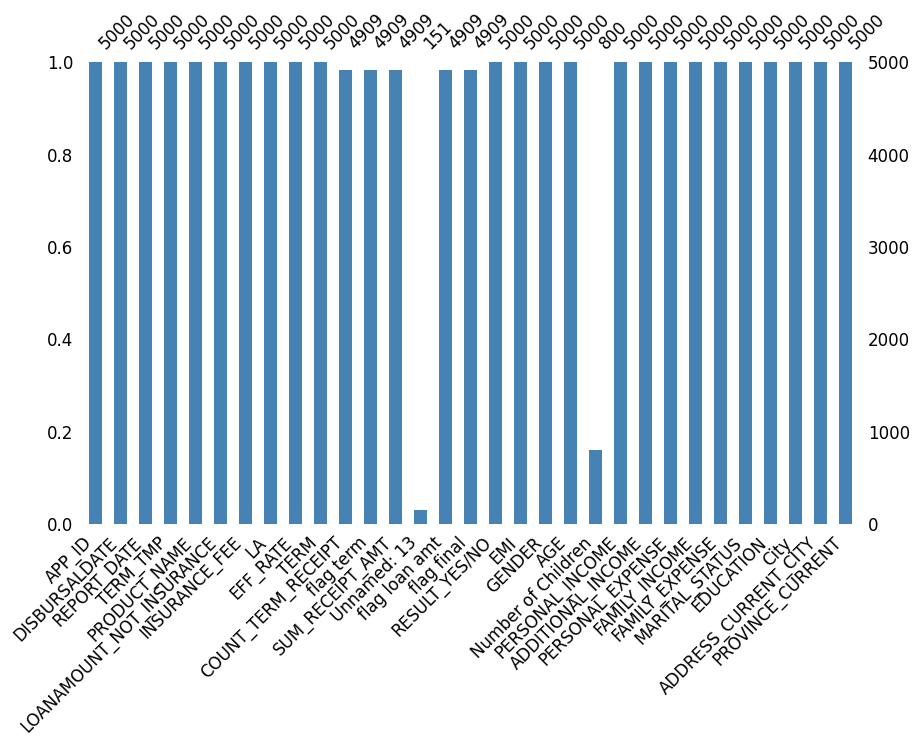

In [37]:
%matplotlib inline
msno.bar(df, figsize=(10, 6), fontsize=12, color='steelblue', )


<Axes: >

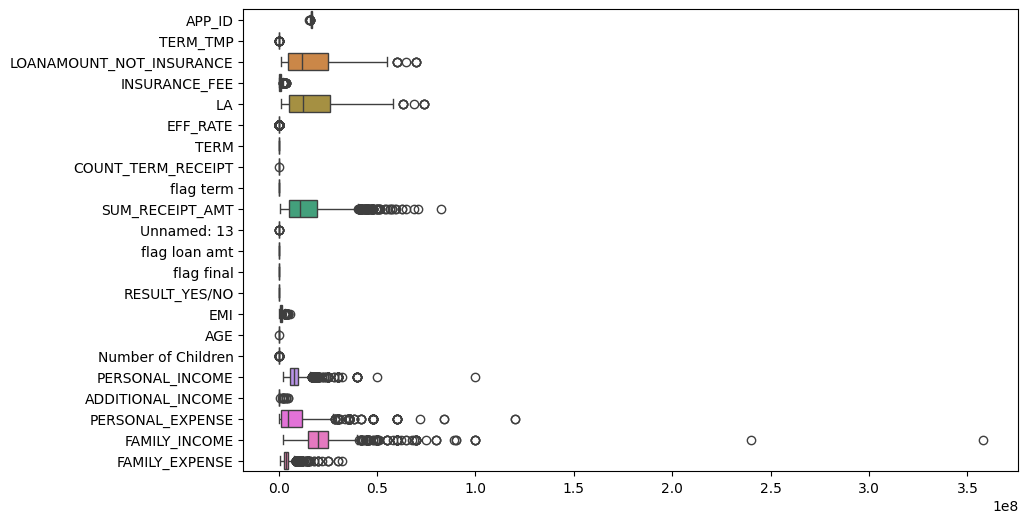

In [62]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, orient='h')

<Axes: >

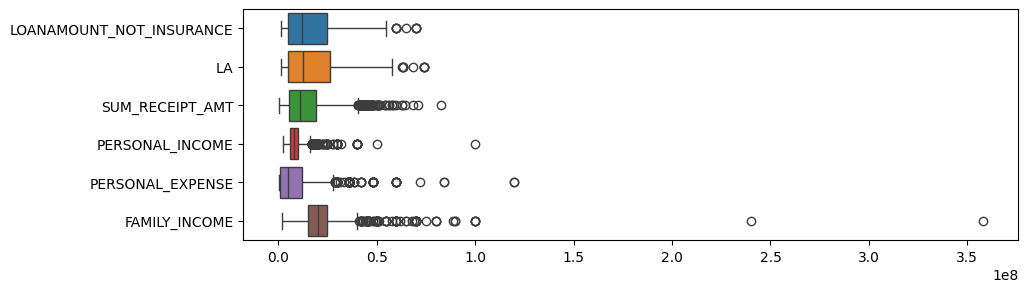

In [65]:
plt.figure(figsize=(10, 3))
sns.boxplot(data=df[['LOANAMOUNT_NOT_INSURANCE', 'LA', 'SUM_RECEIPT_AMT', 'PERSONAL_INCOME', 'PERSONAL_EXPENSE', 'FAMILY_INCOME']], orient='h')

<Axes: >

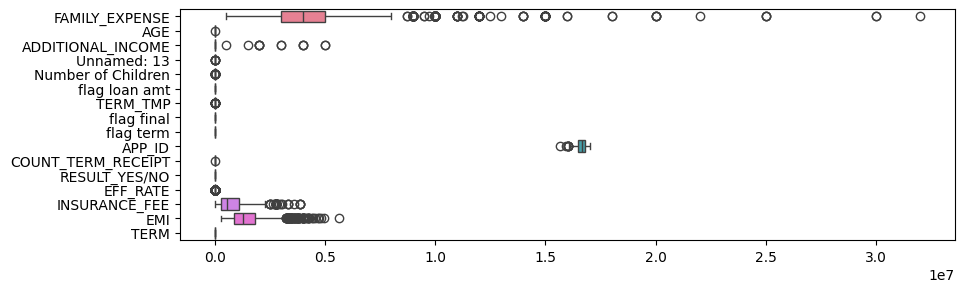

In [60]:
plt.figure(figsize=(10, 3))
sns.boxplot(data=df[list(set(df.columns) - set(['LOANAMOUNT_NOT_INSURANCE', 'LA', 'SUM_RECEIPT_AMT', 'PERSONAL_INCOME', 'PERSONAL_EXPENSE', 'FAMILY_INCOME']))], orient='h')

### Summary Statistics of Numerical Columns

In [9]:
df.describe()

,APP_ID,DISBURSALDATE,REPORT_DATE,TERM_TMP,LOANAMOUNT_NOT_INSURANCE,INSURANCE_FEE,LA,EFF_RATE,TERM,COUNT_TERM_RECEIPT,...,flag final,RESULT_YES/NO,EMI,AGE,Number of Children,PERSONAL_INCOME,ADDITIONAL_INCOME,PERSONAL_EXPENSE,FAMILY_INCOME,FAMILY_EXPENSE
count,5.000000e+03,5000,5000,5000.000000,5.000000e+03,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4909.000000,...,4909.000000,5000.000000,5.000000e+03,5000.000000,800.000000,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03
mean,1.664263e+07,2017-10-16 22:06:14.400000,2018-10-26 00:00:00,12.003200,1.564802e+07,7.934629e+05,1.644148e+07,36.797372,15.046800,8.464046,...,0.618456,0.727200,1.373196e+06,34.283000,1.760000,8.563299e+06,7.600000e+03,8.464034e+06,2.180893e+07,4.473954e+06
min,1.567386e+07,2017-10-01 00:00:00,2018-10-26 00:00:00,11.000000,1.200000e+06,0.000000e+00,1.260000e+06,0.000000,3.000000,1.000000,...,0.000000,0.000000,2.660000e+05,18.000000,0.000000,2.200000e+06,0.000000e+00,2.000000e+05,2.000000e+06,5.000000e+05
25%,1.649293e+07,2017-10-10 00:00:00,2018-10-26 00:00:00,12.000000,4.940000e+06,2.536380e+05,5.215938e+06,33.500000,6.000000,6.000000,...,0.000000,0.000000,8.435000e+05,26.000000,1.000000,6.000000e+06,0.000000e+00,1.000000e+06,1.500000e+07,3.000000e+06
50%,1.664363e+07,2017-10-17 00:00:00,2018-10-26 00:00:00,12.000000,1.200000e+07,5.500000e+05,1.266000e+07,44.500000,12.000000,9.000000,...,1.000000,1.000000,1.278378e+06,33.000000,2.000000,8.000000e+06,0.000000e+00,4.900000e+06,2.000000e+07,4.000000e+06
75%,1.679488e+07,2017-10-24 00:00:00,2018-10-26 00:00:00,12.000000,2.500000e+07,1.100000e+06,2.637500e+07,47.000000,24.000000,12.000000,...,1.000000,1.000000,1.785462e+06,41.000000,2.000000,1.000000e+07,0.000000e+00,1.200000e+07,2.500000e+07,5.000000e+06
max,1.700631e+07,2017-10-31 00:00:00,2018-10-26 00:00:00,13.000000,7.000000e+07,3.850000e+06,7.385000e+07,85.000000,36.000000,24.000000,...,1.000000,1.000000,5.632000e+06,99.000000,8.000000,1.000000e+08,5.000000e+06,1.200000e+08,3.580000e+08,3.200000e+07
std,1.892634e+05,NaN,NaN,0.059921,1.196323e+07,6.654844e+05,1.255701e+07,21.158261,8.907776,3.369312,...,0.485815,0.445443,6.898423e+05,9.898874,0.939949,4.176414e+06,1.638524e+05,9.692969e+06,1.124716e+07,2.307437e+06


### Correlation Heatmap

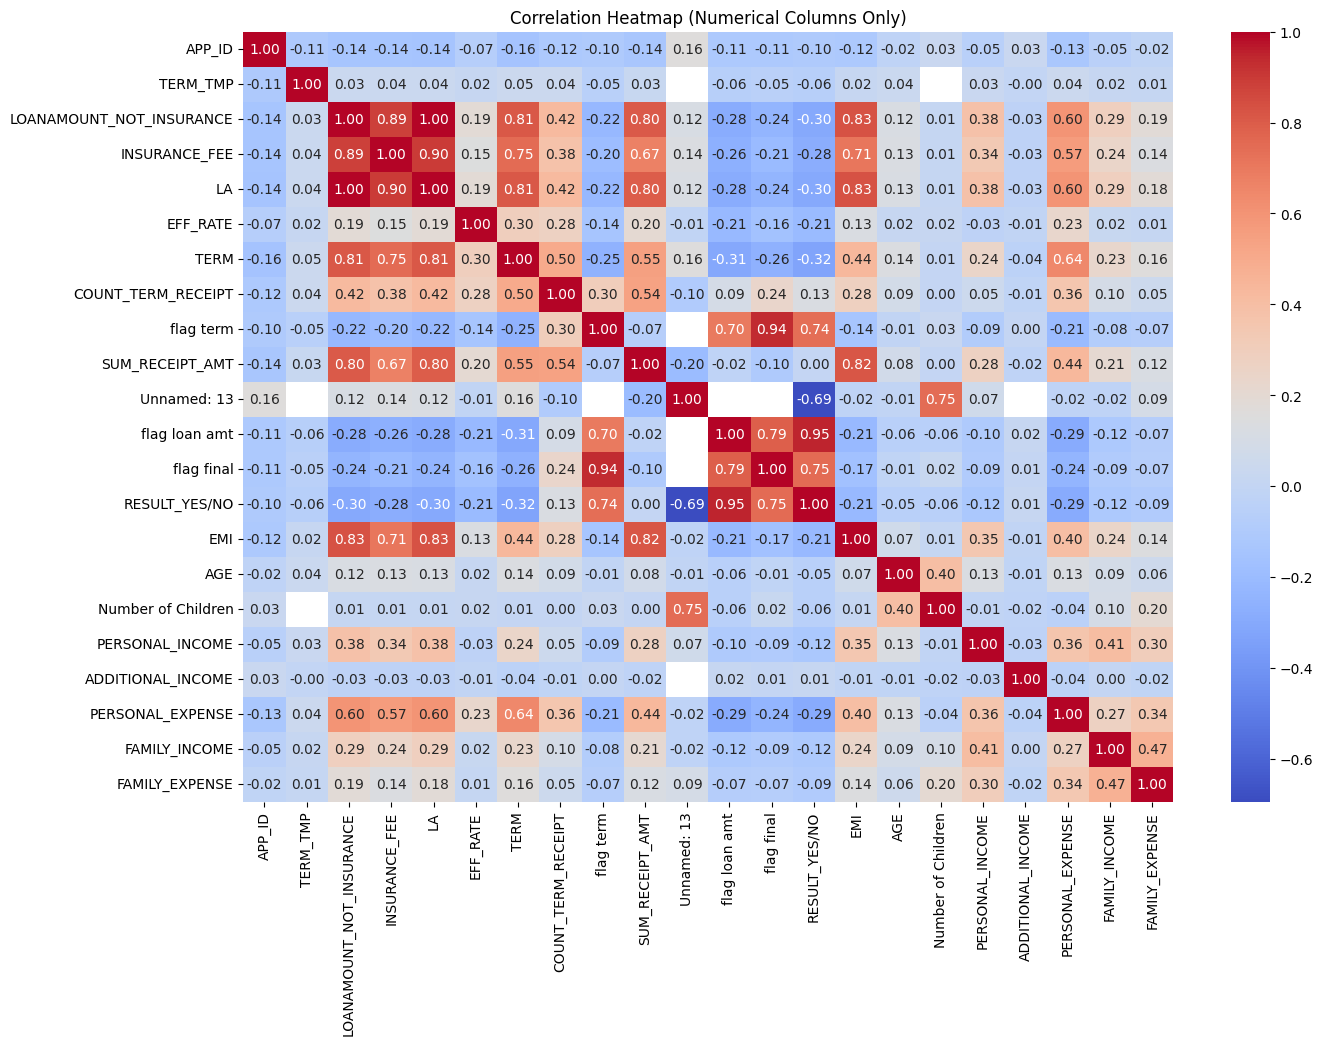

In [17]:
# Updated Correlation Heatmap with Only Numerical Columns
numerical_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(15, 10))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numerical Columns Only)')
plt.show()

### Distribution of Loan Amounts

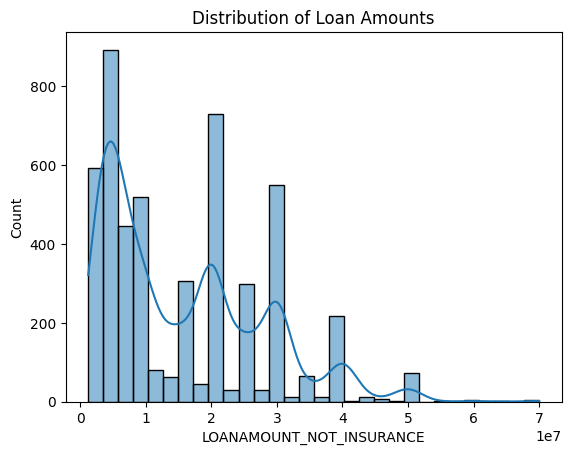

In [12]:
sns.histplot(df['LOANAMOUNT_NOT_INSURANCE'], kde=True)
plt.title('Distribution of Loan Amounts')
plt.show()

### Loan Amount by Education Level

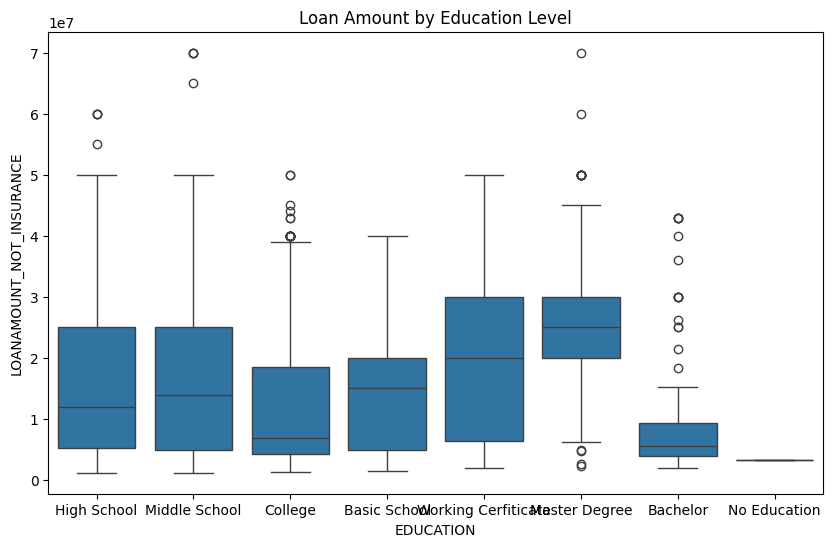

In [39]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='EDUCATION', y='LOANAMOUNT_NOT_INSURANCE', data=df)
plt.title('Loan Amount by Education Level')
plt.show()

### Loan Amount by Marital Status

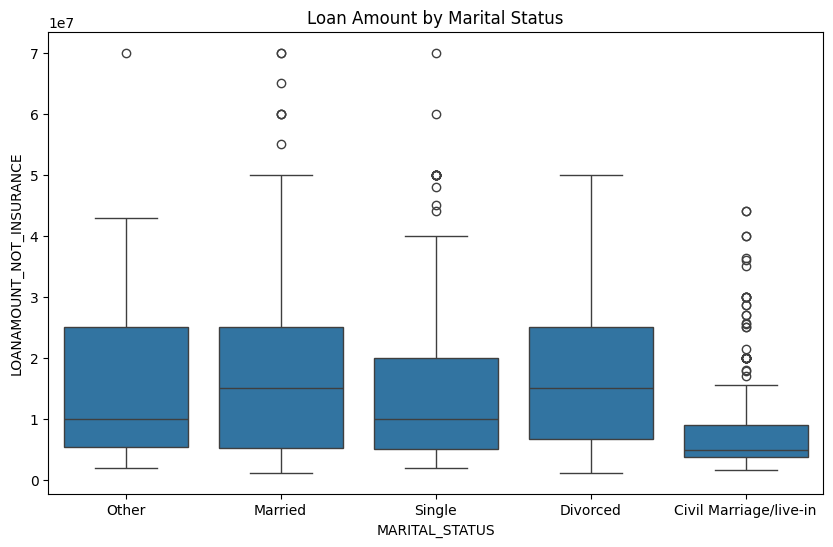

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='MARITAL_STATUS', y='LOANAMOUNT_NOT_INSURANCE', data=df)
plt.title('Loan Amount by Marital Status')
plt.show()

### Distribution of Effective Rate

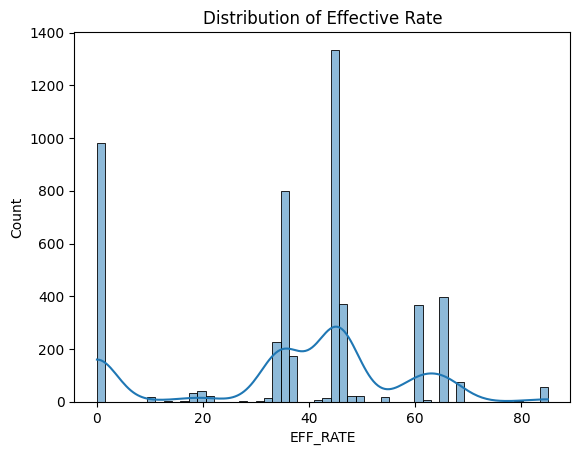

In [15]:
sns.histplot(df['EFF_RATE'], kde=True)
plt.title('Distribution of Effective Rate')
plt.show()

### Relationship between Personal Income and Loan Amount

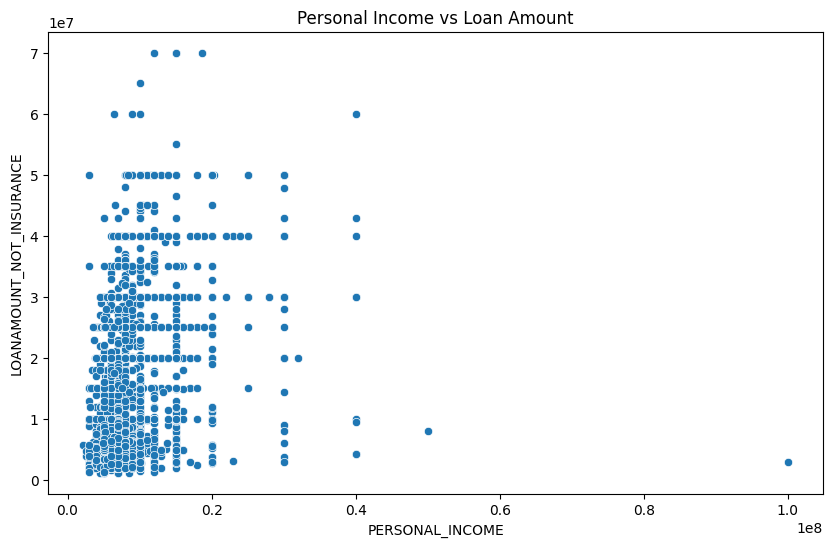

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PERSONAL_INCOME', y='LOANAMOUNT_NOT_INSURANCE', data=df)
plt.title('Personal Income vs Loan Amount')
plt.show()